In [27]:
# Veri işleme, görselleştirme ve modelleme için gerekli kütüphaneleri yüklüyoruz
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Model oluşturma ve veri bölme fonksiyonları
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Model performansını ölçmek için metrikler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [28]:
# day5 klasörü içine kopyaladığımız veri setini okuyoruz
df = pd.read_csv("students_data.csv")

# Sütun isimlerindeki olası boşluk hatalarını engellemek için temizliyoruz
df.columns = df.columns.str.strip()

# Yüklenen verinin ilk 5 satırını ve sütun isimlerini görüntülüyoruz
print("--- Sütun İsimleri ---")
print(df.columns.tolist())

print("\n--- İlk 5 Satır ---")
df.head()

--- Sütun İsimleri ---
['Student_Name', 'Age', 'Gender', 'Course', 'Attendance', 'Assignment_Score', 'Midterm_Score', 'Final_Score']

--- İlk 5 Satır ---


,Student_Name,Age,Gender,Course,Attendance,Assignment_Score,Midterm_Score,Final_Score
0,Alice,24,Female,AI/ML,85.0,90.0,80.0,85.0
1,Bob,22,Male,Data Science,62.0,55.0,60.0,58.0
2,Charlie,21,Male,AI/ML,90.0,95.0,88.0,92.0
3,David,23,Male,Web Dev,45.0,50.0,40.0,42.0
4,Emma,26,Female,AI/ML,70.0,NaN,65.0,60.0


In [29]:
# Tüm sayısal sütunlardaki eksik (NaN) değerleri kendi ortalamalarıyla (mean) dolduruyoruz
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# Kalan eksik değer kontrolü
print("Kalan Eksik Değer Sayısı:")
print(df.isnull().sum())

Kalan Eksik Değer Sayısı:
Student_Name        0
Age                 0
Gender              0
Course              0
Attendance          0
Assignment_Score    0
Midterm_Score       0
Final_Score         0
dtype: int64


In [30]:
# 1. Hedef Değişkeni (y) Hazırlama:
# Eğer 'Passed' sütunu yoksa, not sütununa göre (örneğin Exam_Score >= 50) oluşturuyoruz
if 'Passed' not in df.columns:
    # Veride geçen muhtemel sınav notu sütun isimlerini kontrol et
    score_col = None
    for col in ['Exam_Score', 'Final_Exam', 'Score', 'Grade']:
        if col in df.columns:
            score_col = col
            break
            
    if score_col:
        # Notu 50 ve üzeri olanlar geçti (1), altında olanlar kaldı (0)
        df['Passed'] = (df[score_col] >= 50).astype(int)
        print(f"'{score_col}' sütunu kullanılarak 'Passed' hedef değişkeni oluşturuldu.")
    else:
        # Not sütunu da yoksa son sayısal sütunu hedef değişken kabul et
        df['Passed'] = (df.iloc[:, -1] >= df.iloc[:, -1].median()).astype(int)
        print("Hedef değişken veri setinin son sütununa göre otomatik oluşturuldu.")

# 2. Öznitelikler (X) ve Hedef Değişken (y) Seçimi:
# Hedef değişken ve metinsel/kimlik sütunlarını X'ten çıkarıyoruz
drop_cols = ['Student_ID', 'Name', 'Passed', 'Exam_Score', 'Final_Exam', 'Score', 'Grade']
feature_cols = [col for col in df.columns if col not in drop_cols and df[col].dtype in [np.int64, np.float64]]

X = df[feature_cols]
y = df['Passed']

print("\n--- Model Girdileri ---")
print("Kullanılan Öznitelikler (X):", list(X.columns))
print("Hedef Değişken (y) Dağılımı:\n", y.value_counts())

Hedef değişken veri setinin son sütununa göre otomatik oluşturuldu.

--- Model Girdileri ---
Kullanılan Öznitelikler (X): ['Age', 'Attendance', 'Assignment_Score', 'Midterm_Score', 'Final_Score']
Hedef Değişken (y) Dağılımı:
 Passed
1    15
0    15
Name: count, dtype: int64


In [31]:
# Verinin %80'ini eğitim (train), %20'sini test seti olarak ayırıyoruz
# random_state=42 parametresi sonuçların her çalıştırıldığında aynı çıkmasını sağlar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Eğitim Seti Boyutu: {X_train.shape[0]} örnek")
print(f"Test Seti Boyutu: {X_test.shape[0]} örnek")

Eğitim Seti Boyutu: 24 örnek
Test Seti Boyutu: 6 örnek


In [32]:
# 1. Logistic Regression Modelinin Oluşturulması ve Eğitilmesi
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

# 2. Decision Tree Modelinin Oluşturulması ve Eğitilmesi
dec_tree = DecisionTreeClassifier(random_state=42, max_depth=4)
dec_tree.fit(X_train, y_train)

print("Her iki model de başarıyla eğitildi!")

Her iki model de başarıyla eğitildi!


In [33]:
# Test seti üzerinde tahminlerin alınması
y_pred_log = log_reg.predict(X_test)
y_pred_tree = dec_tree.predict(X_test)

# Performans metriklerini hesaplayan bir yardımcı fonksiyon
def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0)
    }

# Sonuçları karşılaştırmalı DataFrame haline getirme
results = pd.DataFrame({
    "Logistic Regression": get_metrics(y_test, y_pred_log),
    "Decision Tree": get_metrics(y_test, y_pred_tree)
})

print("--- MODEL KARŞILAŞTIRMA TABLOSU ---")
print(results.round(4))

--- MODEL KARŞILAŞTIRMA TABLOSU ---
           Logistic Regression  Decision Tree
Accuracy                   1.0            1.0
Precision                  1.0            1.0
Recall                     1.0            1.0
F1-Score                   1.0            1.0


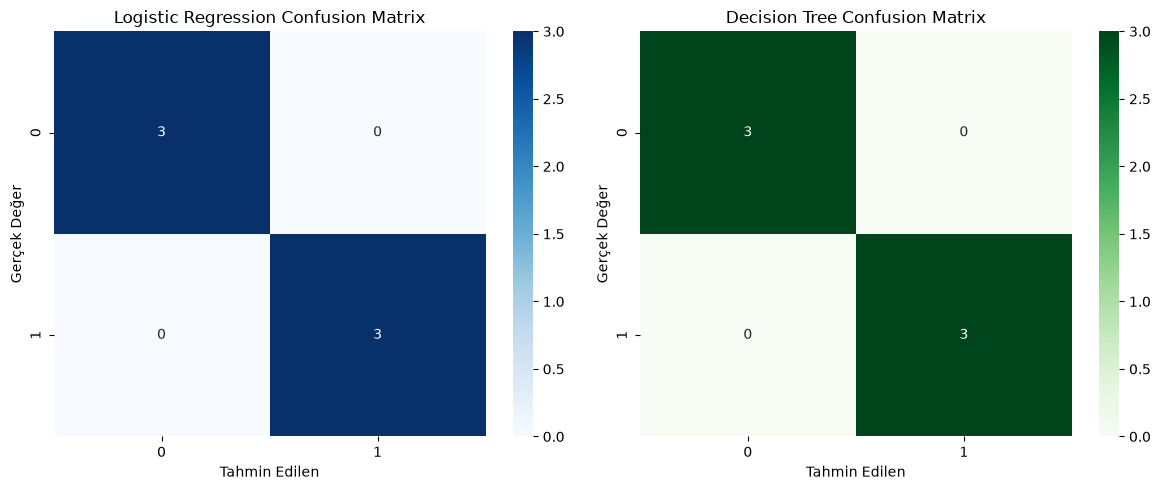

In [35]:
# İki modelin Confusion Matrix'lerini yan yana çizdiriyoruz
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression Matrix (Mavi renk tonları)
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Logistic Regression Confusion Matrix")
axes[0].set_xlabel("Tahmin Edilen")
axes[0].set_ylabel("Gerçek Değer")

# Decision Tree Matrix (Yeşil renk tonları - Greens)
sns.heatmap(confusion_matrix(y_test, y_pred_tree), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title("Decision Tree Confusion Matrix")
axes[1].set_xlabel("Tahmin Edilen")
axes[1].set_ylabel("Gerçek Değer")

plt.tight_layout()
plt.show()